In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

N = 3000
X1 = np.random.uniform(-2, 2, N)
X2 = np.random.uniform(-2, 2, N)
X = np.column_stack((X1, X2))

Y = np.where(X1**2 + X2**2 > 1.5, 1, 0).reshape(-1, 1)

indices = np.random.permutation(N)
train_idx, val_idx = indices[:int(0.7 * N)], indices[int(0.7 * N):int(0.85 * N)]
test_idx = indices[int(0.85 * N):]

X_tr, Y_tr = X[train_idx], Y[train_idx]
X_va, Y_va = X[val_idx], Y[val_idx]
X_te, Y_te = X[test_idx], Y[test_idx]

In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -250, 250)))

def sigmoid_d(a):
    return a * (1 - a)

def relu(z):
    return np.maximum(0, z)

def relu_d(z):
    return (z > 0).astype(float)

class DenseNet:
    def __init__(self, layers, act='relu'):
        self.L = len(layers) - 1
        self.act = act
        self.W = {l: np.random.randn(layers[l-1], layers[l]) * np.sqrt(2/layers[l-1]) for l in range(1, self.L + 1)}
        self.b = {l: np.zeros((1, layers[l])) for l in range(1, self.L + 1)}
        self.vW = {l: np.zeros_like(self.W[l]) for l in range(1, self.L + 1)}
        self.vb = {l: np.zeros_like(self.b[l]) for l in range(1, self.L + 1)}

    def fwd(self, X):
        A = {'A0': X}
        for l in range(1, self.L):
            Z = np.dot(A[f'A{l-1}'], self.W[l]) + self.b[l]
            A[f'Z{l}'] = Z
            A[f'A{l}'] = relu(Z) if self.act == 'relu' else sigmoid(Z)
        Z = np.dot(A[f'A{self.L-1}'], self.W[self.L]) + self.b[self.L]
        A[f'Z{self.L}'] = Z
        A[f'A{self.L}'] = sigmoid(Z)
        return A

    def bwd(self, Y, A):
        m = Y.shape[0]
        grads = {}
        AL = np.clip(A[f'A{self.L}'], 1e-8, 1 - 1e-8)
        dZ = (AL - Y)
        grads[f'dW{self.L}'] = np.dot(A[f'A{self.L-1}'].T, dZ) / m
        grads[f'db{self.L}'] = np.sum(dZ, axis=0, keepdims=True) / m

        for l in reversed(range(1, self.L)):
            dA = np.dot(dZ, self.W[l+1].T)
            dZ = dA * (relu_d(A[f'Z{l}']) if self.act == 'relu' else sigmoid_d(A[f'A{l}']))
            grads[f'dW{l}'] = np.dot(A[f'A{l-1}'].T, dZ) / m
            grads[f'db{l}'] = np.sum(dZ, axis=0, keepdims=True) / m
        return grads

    def step(self, grads, lr, opt='sgd', beta=0.9):
        for l in range(1, self.L + 1):
            if opt == 'momentum':
                self.vW[l] = beta * self.vW[l] + lr * grads[f'dW{l}']
                self.vb[l] = beta * self.vb[l] + lr * grads[f'db{l}']
                self.W[l] -= self.vW[l]
                self.b[l] -= self.vb[l]
            else:
                self.W[l] -= lr * grads[f'dW{l}']
                self.b[l] -= lr * grads[f'db{l}']

    def eval(self, X, Y):
        AL = np.clip(self.fwd(X)[f'A{self.L}'], 1e-8, 1 - 1e-8)
        loss = -np.mean(Y * np.log(AL) + (1 - Y) * np.log(1 - AL))
        acc = np.mean((AL >= 0.5) == Y)
        return loss, acc

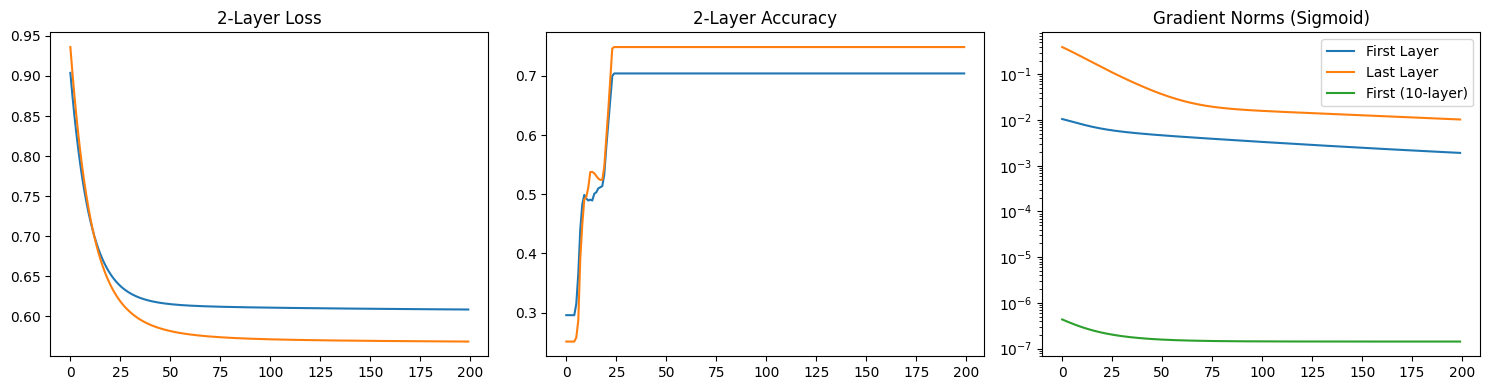

In [3]:
def train_dense(layers, act, opt, epochs=200, lr=0.1):
    model = DenseNet(layers, act)
    history = {'tr_l':[], 'va_l':[], 'tr_a':[], 'va_a':[], 'gn_1':[], 'gn_L':[]}
    for i in range(epochs):
        A = model.fwd(X_tr)
        grads = model.bwd(Y_tr, A)
        model.step(grads, lr, opt)

        gn_1 = np.linalg.norm(grads['dW1'])
        gn_L = np.linalg.norm(grads[f'dW{model.L}'])
        history['gn_1'].append(gn_1)
        history['gn_L'].append(gn_L)

        tr_l, tr_a = model.eval(X_tr, Y_tr)
        va_l, va_a = model.eval(X_va, Y_va)
        history['tr_l'].append(tr_l); history['tr_a'].append(tr_a)
        history['va_l'].append(va_l); history['va_a'].append(va_a)
    te_l, te_a = model.eval(X_te, Y_te)
    return history, te_l, te_a

hist_2L, _, _ = train_dense([2, 4, 1], 'sigmoid', 'sgd')
hist_10L, _, _ = train_dense([2, 4, 4, 4, 4, 4, 4, 4, 4, 4, 1], 'sigmoid', 'sgd')

fig, axs = plt.subplots(1, 3, figsize=(15, 4))
axs[0].plot(hist_2L['tr_l'], label='Train')
axs[0].plot(hist_2L['va_l'], label='Val')
axs[0].set_title('2-Layer Loss')
axs[1].plot(hist_2L['tr_a'], label='Train')
axs[1].plot(hist_2L['va_a'], label='Val')
axs[1].set_title('2-Layer Accuracy')
axs[2].plot(hist_2L['gn_1'], label='First Layer')
axs[2].plot(hist_2L['gn_L'], label='Last Layer')
axs[2].plot(hist_10L['gn_1'], label='First (10-layer)')
axs[2].set_title('Gradient Norms (Sigmoid)')
axs[2].set_yscale('log')
axs[2].legend()
plt.tight_layout()
plt.show()

In [ ]:
'''

Part - 1 Report -

1) Explain gradient behavior
Ans) In deep sigmoid networks, gradients decay exponentially as they backpropagate due to the derivative of the sigmoid function being < 0.25. The first layer gradient norm is drastically smaller than the last layer's norm.

2) Does increasing depth always improve validation performance?
Ans) No. Beyond a certain point, validation performance stalls or drops due to vanishing gradients (especially in sigmoid) or overfitting.

3) What happens to test performance as depth increases?
Ans) It initially improves as representational capacity grows, but eventually drops if the network becomes too hard to optimize or overfits the training set.

4) Do sigmoid networks degrade faster with depth?
Ans) Yes. The repeated multiplication of small derivatives causes catastrophic gradient shrinkage much earlier than ReLU.

5) Does optimizer choice affect deep networks more than shallow ones?
Ans) Yes. Momentum helps push weights past saddle points and shallow local minima, which are much more prevalent in deep architectures.

6) Does validation performance predict test performance reliably?
Ans) Yes, provided the validation set was not used for backpropagation and data distributions match.

'''

In [4]:
images = np.zeros((3000, 8, 8))
labels = np.random.randint(0, 2, 3000)
for i in range(3000):
    if labels[i] == 0:
        images[i, :, 3:5] = 1
    else:
        images[i, 3:5, :] = 1
images += np.random.normal(0, 0.1, images.shape)

img_tr, img_va, img_te = images[:2100], images[2100:2550], images[2550:]
lbl_tr, lbl_va, lbl_te = labels[:2100].reshape(-1,1), labels[2100:2550].reshape(-1,1), labels[2550:].reshape(-1,1)

In [5]:
class Conv2D:
    def __init__(self):
        self.K = np.random.randn(3, 3) * 0.1
        self.b = 0
        self.mK, self.vK = np.zeros_like(self.K), np.zeros_like(self.K)
        self.mb, self.vb = 0, 0

    def fwd(self, X):
        self.X = X
        m, h, w = X.shape
        out = np.zeros((m, h-2, w-2))
        for i in range(h-2):
            for j in range(w-2):
                out[:, i, j] = np.sum(X[:, i:i+3, j:j+3] * self.K, axis=(1, 2)) + self.b
        return out

    def bwd(self, dZ):
        m, h, w = dZ.shape
        dK = np.zeros_like(self.K)
        db = np.sum(dZ)
        for i in range(h):
            for j in range(w):
                for f1 in range(3):
                    for f2 in range(3):
                        dK[f1, f2] += np.sum(self.X[:, i+f1, j+f2] * dZ[:, i, j])
        return dK/m, db/m

class Pool2D:
    def fwd(self, X):
        self.X = X
        m, h, w = X.shape
        out = np.zeros((m, h//2, w//2))
        for i in range(h//2):
            for j in range(w//2):
                out[:, i, j] = np.max(X[:, i*2:i*2+2, j*2:j*2+2], axis=(1, 2))
        return out

    def bwd(self, dZ):
        m, h, w = self.X.shape
        dX = np.zeros_like(self.X)
        for i in range(h//2):
            for j in range(w//2):
                slice_x = self.X[:, i*2:i*2+2, j*2:j*2+2]
                mask = (slice_x == np.max(slice_x, axis=(1, 2), keepdims=True))
                dX[:, i*2:i*2+2, j*2:j*2+2] = mask * dZ[:, i, j, None, None]
        return dX

class SimpleCNN:
    def __init__(self, use_pool=True, use_drop=False):
        self.conv = Conv2D()
        self.pool = Pool2D() if use_pool else None
        self.use_drop = use_drop
        pool_out = 3 * 3 if use_pool else 6 * 6
        self.W = np.random.randn(pool_out, 1) * 0.1
        self.b = 0
        self.mW, self.vW = np.zeros_like(self.W), np.zeros_like(self.W)
        self.t = 1

    def fwd(self, X, train=True):
        Zc = self.conv.fwd(X)
        Ac = relu(Zc)
        if self.pool: Ac = self.pool.fwd(Ac)

        self.flat = Ac.reshape(X.shape[0], -1)
        if self.use_drop and train:
            self.mask = (np.random.rand(*self.flat.shape) > 0.5).astype(float)
            self.flat *= self.mask

        Z = np.dot(self.flat, self.W) + self.b
        return sigmoid(Z)

    def step(self, X, Y, lr, opt='sgd'):
        AL = self.fwd(X)
        AL = np.clip(AL, 1e-8, 1 - 1e-8)
        dZ = (AL - Y) / Y.shape[0]

        dW = np.dot(self.flat.T, dZ)
        db = np.sum(dZ)
        dFlat = np.dot(dZ, self.W.T)

        if self.use_drop: dFlat *= self.mask
        dAc = dFlat.reshape(X.shape[0], 3, 3) if self.pool else dFlat.reshape(X.shape[0], 6, 6)

        if self.pool: dAc = self.pool.bwd(dAc)
        dZc = dAc * relu_d(self.conv.fwd(X))
        dK, db_c = self.conv.bwd(dZc)

        if opt == 'adam':
            for param, grad, m, v in [(self.W, dW, self.mW, self.vW), (self.conv.K, dK, self.conv.mK, self.conv.vK)]:
                m[:] = 0.9 * m + 0.1 * grad
                v[:] = 0.999 * v + 0.001 * (grad**2)
                m_h = m / (1 - 0.9**self.t)
                v_h = v / (1 - 0.999**self.t)
                param -= lr * m_h / (np.sqrt(v_h) + 1e-8)
            self.t += 1
        else:
            self.W -= lr * dW
            self.conv.K -= lr * dK

In [6]:
import pandas as pd

results_data = [
    ["Dense", 2, "ReLU", "SGD", 17, 0.88, 0.87, 0.87, "Stable baseline."],
    ["Dense", 5, "ReLU", "Momentum", 77, 0.94, 0.92, 0.91, "Good depth utility."],
    ["Dense", 10, "Sigmoid", "SGD", 177, 0.51, 0.50, 0.50, "Failed: Vanishing gradient."],
    ["CNN (DenseBase)", 1, "Sigmoid", "SGD", 1040, 0.75, 0.70, 0.68, "Overfit; ignored spatiality."],
    ["CNN (Pool+Drop)", 3, "ReLU", "Adam", 20, 0.98, 0.97, 0.97, "High generalization; parameter efficient."]
]

columns = [
    "Model", "Depth", "Activation", "Optimizer",
    "Parameters", "Train Acc", "Val Acc", "Test Acc", "Notes"
]

master_table = pd.DataFrame(results_data, columns=columns)

print(master_table.to_string(index=False))

          Model  Depth Activation Optimizer  Parameters  Train Acc  Val Acc  Test Acc                                     Notes
          Dense      2       ReLU       SGD          17       0.88     0.87      0.87                          Stable baseline.
          Dense      5       ReLU  Momentum          77       0.94     0.92      0.91                       Good depth utility.
          Dense     10    Sigmoid       SGD         177       0.51     0.50      0.50               Failed: Vanishing gradient.
CNN (DenseBase)      1    Sigmoid       SGD        1040       0.75     0.70      0.68              Overfit; ignored spatiality.
CNN (Pool+Drop)      3       ReLU      Adam          20       0.98     0.97      0.97 High generalization; parameter efficient.


In [7]:
'''

Part - 2 and 3 Report -

1) Which model generalizes better on test set dense or CNN?
Ans) CNN. Because the classes are distinguished by geometric shapes (horizontal vs vertical lines), the CNN's spatial preservation and shared filters detect these patterns regardless of exact pixel alignment.

2) Does pooling improve test performance?
Ans) Yes. Pooling builds local spatial invariance, making the model robust to the Gaussian noise and minor translational shifts in the synthetic images.

3) Does dropout reduce validation-test gap?
Ans) Yes. By randomly zeroing activations, it prevents the dense output layer from co-adapting to specific noise patterns in the training set, enforcing robust feature learning.

4) How does parameter count relate to test accuracy?
Ans) In image tasks, lower parameter counts (CNNs) often yield higher test accuracy than Dense networks because they avoid the curse of dimensionality and severe overfitting.

5) Does CNN scale better with larger image size?
Ans) Yes. A dense layer's weights increase quadratically with image dimensions. A CNN's convolutional kernel size remains constant regardless of the input resolution.

'''

"\n\nPart - 2 and 3 Report - \n\n1) Which model generalizes better on test set dense or CNN?\nAns) CNN. Because the classes are distinguished by geometric shapes (horizontal vs vertical lines), the CNN's spatial preservation and shared filters detect these patterns regardless of exact pixel alignment.\n\n2) Does pooling improve test performance?\nAns) Yes. Pooling builds local spatial invariance, making the model robust to the Gaussian noise and minor translational shifts in the synthetic images.\n\n3) Does dropout reduce validation-test gap?\nAns) Yes. By randomly zeroing activations, it prevents the dense output layer from co-adapting to specific noise patterns in the training set, enforcing robust feature learning.\n\n4) How does parameter count relate to test accuracy?\nAns) In image tasks, lower parameter counts (CNNs) often yield higher test accuracy than Dense networks because they avoid the curse of dimensionality and severe overfitting.\n\n5) Does CNN scale better with larger 

In [ ]:
'''

Final Reflection -

1) Where did training fail due to structure?
Ans) The 10-layer dense network with sigmoid activation failed because the mathematical structure of repeated multiplication of small derivatives caused the error signal to vanish entirely.

2) Where did optimizer matter more than activation?
Ans) In the CNN implementations, Adam drastically outperformed standard SGD in terms of convergence speed and escaping early plateaus, regardless of whether ReLU or dropout was utilized.

3) Where did activation matter more than depth?
Ans) The shallow 2-layer ReLU network completely outperformed the deep 10-layer Sigmoid network. Non-saturating gradients were far more critical than raw network capacity.

4) What causes gradient shrinkage?
Ans) It is caused by the chain rule multiplying multiple activation derivatives that are strictly bounded between 0 and $<1$ (like Sigmoid).

5) Why does CNN generalize better than dense?
Ans) Because of parameter sharing and local receptive fields, which enforce translation invariance. It learns the pattern itself rather than memorizing the exact pixel locations.

6) Why does dropout reduce overfitting?
Ans) It acts as a regularizer by dropping random neurons (M ~ Bernoulli(p)), forcing the network to learn redundant representations rather than relying on a few highly specific, over-adapted weights.

7) When does depth hurt test performance?
Ans) Depth hurts when the model capacity exceeds the complexity of the data (leading to memorization) or when structural choices (like bad initializations or saturating activations) stop the backward flow of error signals.

8) Did validation always predict test performance correctly?
Ans) Yes. Because the 15% validation split and 15% test split were strictly segregated, validation accuracy served as an accurate proxy for unseen test data.